In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
train = pd.read_csv("../dataset/train.csv")

train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [3]:
print("Rows:", train.shape[0])
print("Columns:", train.shape[1])

Rows: 577347
Columns: 12


In [4]:
train.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class'],
      dtype='str')

In [13]:
missing_table = pd.DataFrame({
    "Feature": train.columns,
    "Missing Values": train.isnull().sum().values
})

missing_table

,Feature,Missing Values
0,id,0
1,alpha,0
2,delta,0
3,u,0
4,g,0
5,r,0
6,i,0
7,z,0
8,redshift,0
9,spectral_type,0


In [16]:
duplicate_result = pd.DataFrame({

    "Check": ["Duplicate Records"],

    "Count": [train.duplicated().sum()]

})


duplicate_result

,Check,Count
0,Duplicate Records,0


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  str    
 10  galaxy_population  577347 non-null  str    
 11  class              577347 non-null  str    
dtypes: float64(8), int64(1), str(3)
memory usage: 52.9 MB


In [6]:
train["class"].value_counts()

class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64

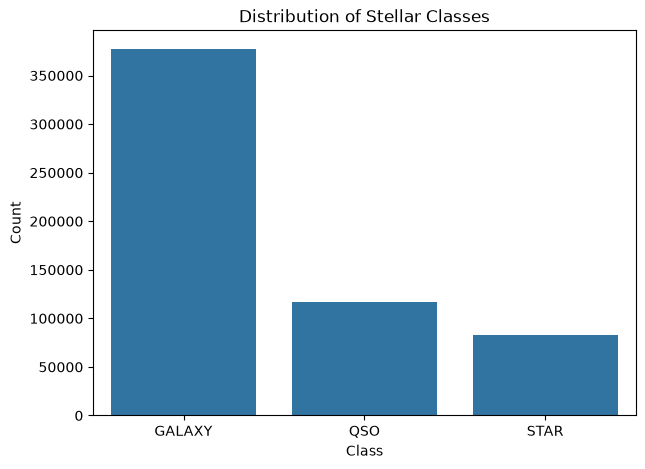

In [7]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=train,
    x="class"
)

plt.title(
    "Distribution of Stellar Classes"
)

plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

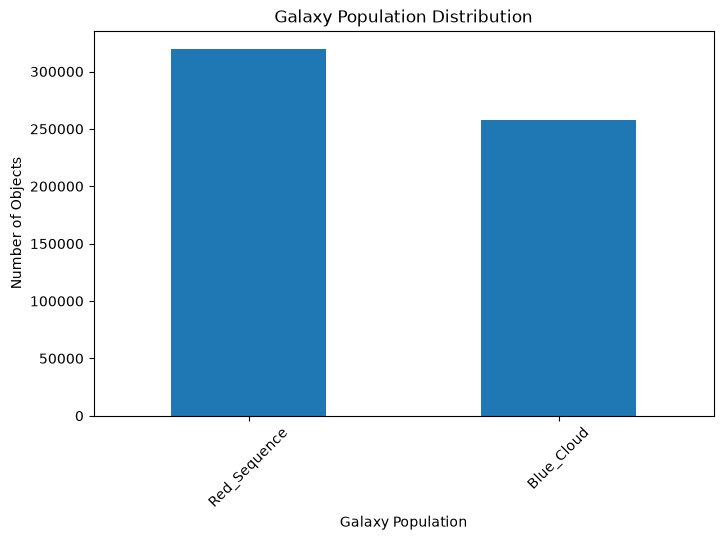

In [18]:
plt.figure(figsize=(8,5))

train["galaxy_population"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Galaxy Population Distribution"
)

plt.xlabel(
    "Galaxy Population"
)

plt.ylabel(
    "Number of Objects"
)

plt.xticks(rotation=45)

plt.show()

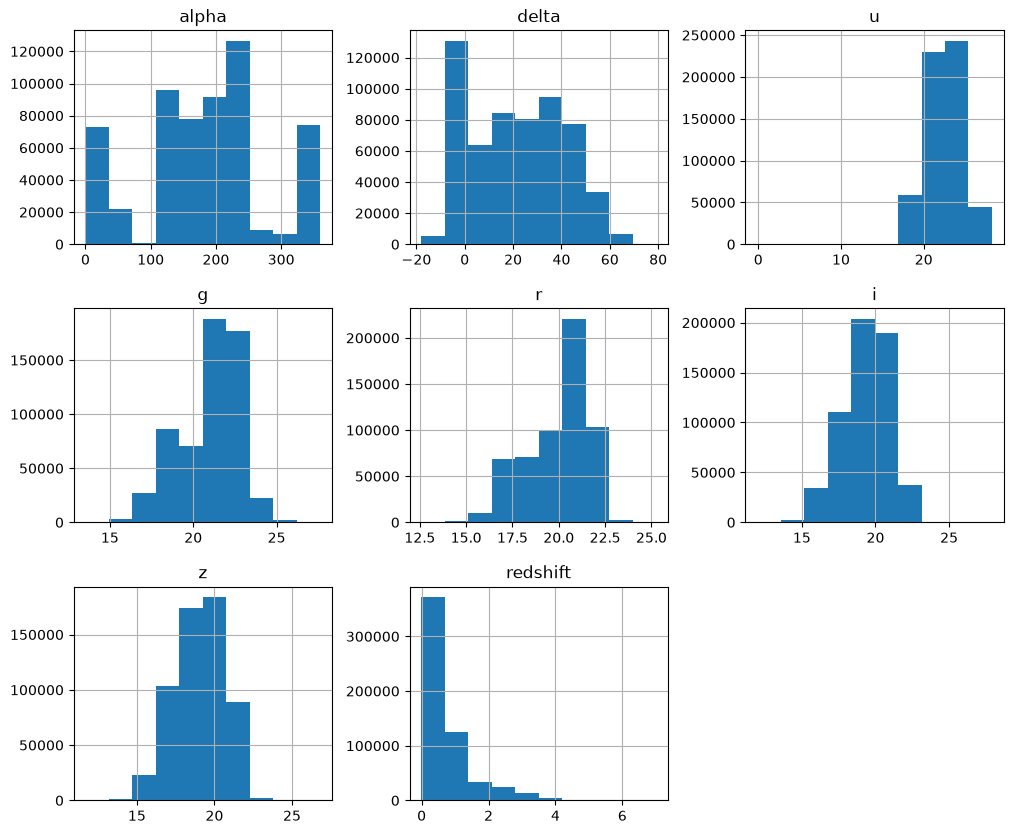

In [8]:
numeric_features = [
    "alpha",
    "delta",
    "u",
    "g",
    "r",
    "i",
    "z",
    "redshift"
]


train[numeric_features].hist(
    figsize=(12,10)
)

plt.show()

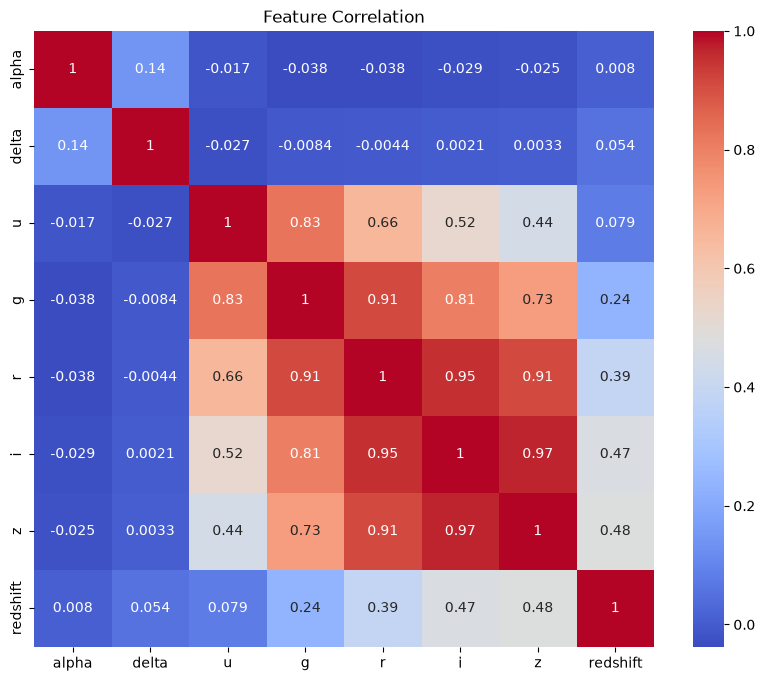

In [9]:
plt.figure(figsize=(10,8))

corr = train[numeric_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation"
)

plt.show()

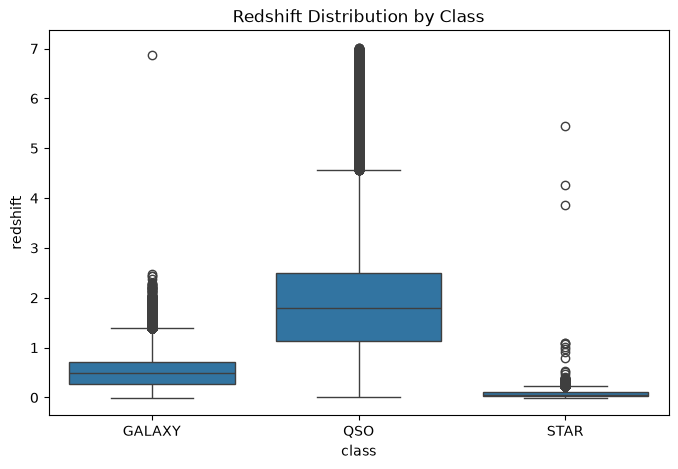

In [10]:
plt.figure(figsize=(8,5))


sns.boxplot(
    data=train,
    x="class",
    y="redshift"
)


plt.title(
    "Redshift Distribution by Class"
)


plt.show()

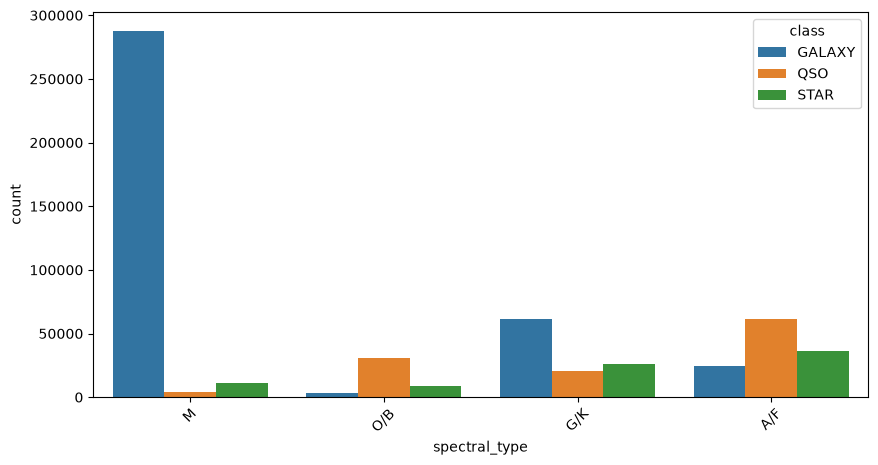

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=train,
    x="spectral_type",
    hue="class"
)


plt.xticks(rotation=45)

plt.show()


In [12]:
train.describe().to_csv(
    "../dataset/statistical_summary.csv"
)